# 第8章 Notebook：ネットワーク恋愛力学

対応章: [`../chapters/08_love_dynamics_network.md`](../chapters/08_love_dynamics_network.md)

この notebook は、卒業研究準備セミナーの数値実験用である。上から順に実行すれば、本文で説明した図を再現できる。設定パラメータは上部のセルにまとめてある。乱数は seed を固定している。

## 1. ライブラリ読み込みと人物リスト

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

np.random.seed(0)
persons = ['A', 'B', 'C']
n = len(persons)

## 2. 感情行列の初期化

`X[i, j]` = 人物 i が j に抱く感情（正=好意, 負=反感, 対角=0）。

In [2]:
rng = np.random.default_rng(0)
X0 = rng.uniform(-0.3, 0.3, size=(n, n))
np.fill_diagonal(X0, 0.0)
print(np.round(X0, 2))

[[ 0.   -0.14 -0.28]
 [-0.29  0.    0.25]
 [ 0.06  0.14  0.  ]]


## 3-4. 更新規則と三角関係モデル

$\dot{x}_{ij}=a\,x_{ij}+b\,x_{ji}+c\sum_{k\neq i,j}x_{kj}+F_{ij}$。第三者効果 `c<0` は「みんなが好きな人に嫉妬して引く」。

In [3]:
def step(X, a, b, c, F, dt):
    colsum = X.sum(axis=0)                 # sum_k x_kj for each j
    third = colsum[None, :] - X            # exclude k=i (x_ij); x_jj=0
    dX = a * X + b * X.T + c * third + F
    np.fill_diagonal(dX, 0.0)
    return X + dt * dX

def simulate(a, b, c, X0, events=None, T=240, dt=0.05):
    events = events or {}
    X = X0.copy(); hist = [X.copy()]
    for t in range(1, T):
        F = events.get(t, np.zeros_like(X))
        X = np.clip(step(X, a, b, c, F, dt), -3, 3)
        hist.append(X.copy())
    return np.array(hist)

a_true, b_true, c_true = -0.10, 0.60, -0.40

## 5. 外部イベント（物語の出来事）

In [4]:
events = {}
F1 = np.zeros((n, n)); F1[0, 1] = 3.0   # A confesses to B at t=80
events[80] = F1
hist = simulate(a_true, b_true, c_true, X0, events)

## 6. 時系列プロット

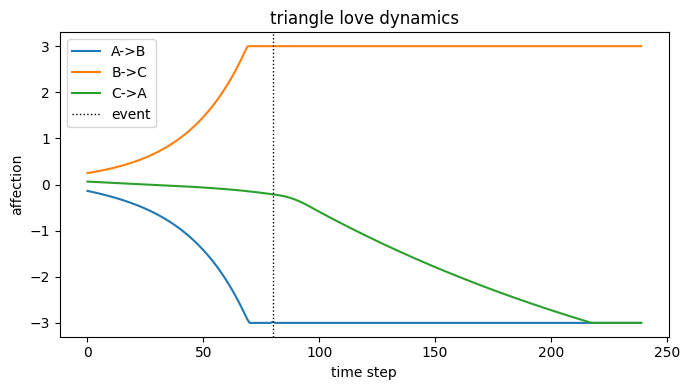

In [5]:
plt.figure(figsize=(7, 4))
for (i, j) in [(0, 1), (1, 2), (2, 0)]:
    plt.plot(hist[:, i, j], label=f'{persons[i]}->{persons[j]}')
plt.axvline(80, color='k', ls=':', lw=1, label='event')
plt.xlabel('time step'); plt.ylabel('affection'); plt.legend()
plt.title('triangle love dynamics'); plt.tight_layout(); plt.show()

## 7. networkx による有向グラフ表示（最終時刻）

/var/folders/6_/q_c40p295y5566q8kzgt8gdm0000gn/T/ipykernel_3228/1699426245.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.title('final emotion network (blue=+, red=-)'); plt.tight_layout(); plt.show()


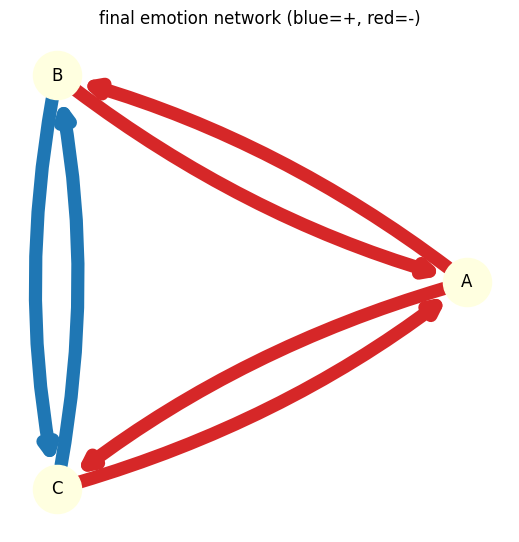

In [6]:
Xf = hist[-1]
G = nx.DiGraph()
for i in range(n):
    for j in range(n):
        if i != j:
            G.add_edge(persons[i], persons[j], weight=Xf[i, j])
pos = nx.circular_layout(G)
edges = list(G.edges(data=True))
colors = ['tab:blue' if d['weight'] >= 0 else 'tab:red' for _, _, d in edges]
widths = [0.5 + 3 * abs(d['weight']) for _, _, d in edges]
plt.figure(figsize=(5, 5))
nx.draw(G, pos, with_labels=True, node_color='lightyellow', node_size=1200,
        edge_color=colors, width=widths, arrowsize=18, connectionstyle='arc3,rad=0.1')
plt.title('final emotion network (blue=+, red=-)'); plt.tight_layout(); plt.show()

## 8. エピソードごとの仮想アノテーションとの比較

「真の」係数で作った軌跡をアノテーション $\hat X$ とみなし、候補 c に対する予測誤差 $L=\sum_t\|X-\hat X\|^2$ を計算する。最小は真値 c 付近になるはず。

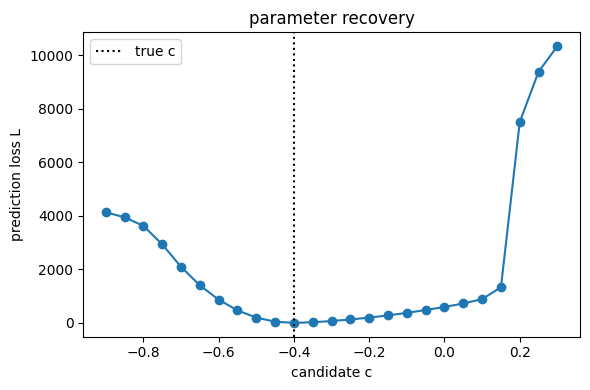

best c = -0.4  (true = -0.4 )


In [7]:
Xhat = simulate(a_true, b_true, c_true, X0, events)
cs = np.linspace(-0.9, 0.3, 25)
loss = [np.sum((simulate(a_true, b_true, c, X0, events) - Xhat) ** 2) for c in cs]
plt.figure(figsize=(6, 4))
plt.plot(cs, loss, 'o-'); plt.axvline(c_true, color='k', ls=':', label='true c')
plt.xlabel('candidate c'); plt.ylabel('prediction loss L'); plt.legend()
plt.title('parameter recovery'); plt.tight_layout(); plt.show()
print('best c =', round(cs[int(np.argmin(loss))], 3), ' (true =', c_true, ')')

## 9. 課題（自分で変更する）

1. `c_true` の符号を正に変えると、三角関係の時系列はどう変わるか。
2. 人物を 4 人に増やし、2 組のカップルが安定する係数を探せ。

In [8]:
# === 課題セル ===
hist_pos = simulate(a_true, b_true, 0.3, X0, events)
print('final emotions with c=+0.3:')
print(np.round(hist_pos[-1], 2))

final emotions with c=+0.3:
[[ 0. -3. -3.]
 [-3.  0. -3.]
 [-3. -3.  0.]]
